# Projekt na przedmiot wyjasnialność modeli w uczeniu maszynowym

Zuzanna Gasik 76650

Celem projektu jest praktyczne zastosowanie metod XAI do analizy i interpretacji modeli uczenia maszynowego. W ramach projektu powstały modele klasyfikacyjne przewidujące szanse na adopcję zwierząt przebywających w schronisku. Analizę przeprowadzono na rzeczywistym zbiorze danych Austin Animal Center Shelter Outcomes, pochodzącym z największego w Stanach Zjednoczonych schroniska dla zwierząt (no-kill shelter), zlokalizowanego w Austin w Teksasie (Źródło danych: https://data.austintexas.gov/Health-and-Community-Services/Austin-Animal-Center-Outcomes-10-01-2013-to-05-05-/9t4d-g238/about_data)

_Oświadczam, że podczas planowania projektu oraz rozwiązywania napotkanych problemów z kodem wspierałam się modelem językowym Gemini._

## Użyte technologie i biblioteki

Projekt został w całości zrealizowany w języku Python. Do poprawnego uruchomienia kodu i reprodukcji wyników wymagane są następujące pakiety:

Przetwarzanie danych i inżynieria cech:

- pandas, numpy – do wczytywania, manipulacji danymi tabelarycznymi oraz wektoryzacji obliczeń.
- re (wbudowany) – do wyrażeń regularnych wykorzystanych przy parsowaniu wieku zwierząt.

Wizualizacja danych:

- matplotlib, seaborn – do podstawowej eksploracyjnej analizy danych (EDA) oraz generowania statycznych wykresów oceny modeli (np. krzywe ROC, krzywe uczenia).
- plotly, nbformat – do generowania interaktywnych wykresów przestrzennych.

Uczenie Maszynowe (Machine Learning):

- scikit-learn –  Pipeline, zastępowanie braków danych, skalowanie, podział zbiorów (train_test_split, StratifiedKFold), implementacja modeli bazowych (Regresja Logistyczna, Random Forest) i ewaluacja metryk.
- xgboost – zaawansowana implementacja modelu gradient boosting użyta jako główny model typu black-box.

Wyjaśnialność modeli (XAI):

- dalex – do wyjaśnień globalnych, w tym obliczania ważności cech na podstawie permutacji (Permutation Feature Importance) oraz generowania profili częściowej zależności (PDP/ICE).
- shap – użyte do generowania stabilnych wyjaśnień lokalnych (wykresy kaskadowe typu Waterfall).
- lime – pakiet do lokalnych, agnostycznych wyjaśnień modeli (Local Interpretable Model-agnostic Explanations), wykorzystany do analizy konkretnych predykcji oraz weryfikacji stabilności przybliżeń.

In [ ]:
#pip install pandas
#pip install matplotlib
#pip install seaborn
#pip install numpy
#pip install -U scikit-learn
#pip install xgboost
#pip install dalex
#pip install nbformat #do interaktywnych wykresów dalex
#pip install shap
#pip install lime

# 1. EDA

Szczegóły zbioru:
Zbiór zawiera szczegółowe informacje o zwierzętach opuszczających schronisko. Na potrzeby projektu oryginalna zmienna docelowa (outcome_type) została przekształcona w problem klasyfikacji binarnej, gdzie celem jest przewidzenie pozytywnego scenariusza, czyli adopcji (klasa 1) względem innych zdarzeń, takich jak eutanazja, transfer czy powrót do właściciela (klasa 0).

W zbiorze znajdują się cechy opisujące m.in.:
- Typ zwierzęcia (animal_type – np. pies, kot),
- Wiek w momencie opuszczenia schroniska (age_upon_outcome – poddany inżynierii cech i zamieniony na liczbę dni),
- Stan reprodukcyjny i płeć (sex_upon_outcome – m.in. sterylizacja/kastracja),
- Rasa oraz ubarwienie (breed, color – pogrupowane w celu zmniejszenia kardynalności).


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Załadowanie zbioru danych
df = pd.read_csv('aac_shelter_outcomes.csv')

# Zamiana zmiennej 'outcome' na problem binarny: 1 dla Adoption, 0 dla reszty
df['is_adopted'] = (df['outcome_type'] == 'Adoption').astype(int)

# Sprawdzenie rozkładu klas
class_counts = df['is_adopted'].value_counts()
class_props = df['is_adopted'].value_counts(normalize=True) * 100

print("--- Rozkład klas (Adoptowane vs Inne) ---")
print(f"Adoptowane (1): {class_counts[1]} ({class_props[1]:.2f}%)")
print(f"Inne (0): {class_counts[0]} ({class_props[0]:.2f}%)")

# Wykres 1: Rozkład klas
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='is_adopted', hue='is_adopted', data=df, palette='Set2', legend=False)
plt.title('Rozkład klas docelowych: Adopcja (1) vs Inne (0)')
plt.xlabel('Został adoptowany (1 = Tak, 0 = Nie)')
plt.ylabel('Liczba zwierząt')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.savefig('rozkad_klas.png', bbox_inches='tight')
plt.close()

# 2. Rodzaj zwierzęcia (Dog vs Cat) a wpływ na adopcje
print("\n--- Analiza typu zwierzęcia (Pies vs Kot) ---")

# Filtr dla psów i kotów
df_dogs_cats = df[df['animal_type'].isin(['Dog', 'Cat'])]
print(df_dogs_cats['animal_type'].value_counts())

# Wykres 2: Szansa na adopcję psów i kotów
plt.figure(figsize=(8, 5))
ax2 = sns.barplot(x='animal_type', y='is_adopted', hue='animal_type', data=df_dogs_cats, palette='Pastel1', errorbar=None, legend=False)
plt.title('Szansa na adopcję: Pies vs Kot')
plt.xlabel('Typ zwierzęcia')
plt.ylabel('Prawdopodobieństwo adopcji')
plt.ylim(0, 1)

# Podpis z procentami
for p in ax2.patches:
    ax2.annotate(f'{p.get_height()*100:.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 8), textcoords='offset points')
plt.savefig('szansa_adopcji_pies_kot.png', bbox_inches='tight')
plt.close()

# Wykres 3: Liczba zwierząt: Pies vs Kot z podziałem na wynik
plt.figure(figsize=(8, 5))
ax3 = sns.countplot(x='animal_type', hue='is_adopted', data=df_dogs_cats, palette='Set2')
plt.title('Liczba zwierząt: Pies vs Kot z podziałem na wynik')
plt.xlabel('Typ zwierzęcia')
plt.ylabel('Liczba zwierząt')
plt.legend(title='Adopcja (1=Tak, 0=Nie)')
plt.savefig('liczba_pies_kot_wynik.png', bbox_inches='tight')
plt.close()

--- Rozkład klas (Adoptowane vs Inne) ---
Adoptowane (1): 33112 (42.31%)
Inne (0): 45144 (57.69%)

--- Analiza typu zwierzęcia (Pies vs Kot) ---
animal_type
Dog    44242
Cat    29422
Name: count, dtype: int64


Analiza rozkładu nowej zmiennej docelowej wykazała, że zbiór jest stosunkowo dobrze zbalansowany:
- Klasa 1 (Adopcja): 33 112 przypadków (42,31%)
- Klasa 0 (Inne zdarzenia): 45 144 przypadków (57,69%)

Zbiór danych z Austin Animal Center jest zdominowany przez dwa główne gatunki: psy (ponad 44 tys. rekordów) oraz koty (ponad 29 tys. rekordów). Wstępna analiza wizualna ujawniła różnice w bazowym prawdopodobieństwie adopcji w zależności od typu zwierzęcia:

- Bazowa szansa na adopcję psa wynosi około 46,5%.
- Bazowa szansa na adopcję kota wynosi około 43,3%.

Choć różnica na poziomie około trzech punktów procentowych wydaje się niewielka, w skali dziesiątek tysięcy zwierząt przewijających się przez schronisko ma ona istotne znaczenie statystyczne i stanowi ważny sygnał decyzyjny dla algorytmów klasyfikacyjnych.

# 2. Preprocessing + pipeline
- przygotowanie do analizy XAI
- zapobieganie wyciekom danych ze zbioru testowego do zbioru treningowego

### Inżynieria cech
Przed podziałem danych na zbiory walidacyjne przeprowadzono dwie kluczowe modyfikacje w strukturze danych:
- Konwersja zmiennej wiekowej: Zamieniono nieregularne wyrażenia i niejednorodne zapisy wieku na ciągłą zmienną numeryczną age_in_days. Wszystkie jednostki czasu (dni, tygodnie, miesiące, lata) zostały sprowadzone do wspólnego mianownika (dni), umożliwiając modelom liniowym i drzewiastym płynną interpretację wieku zwierzęcia.
- Wprowadzenie zmiennej kontrolnej (Sanity Check): Do zbioru danych celowo wprowadzono syntetyczną zmienną random_feature generowaną z rozkładu jednostajnego $U(0, 1)$. Zmienna ta nie niesie żadnej wartości informacyjnej o procesie adopcji. Jej obecność w pipeline ma na celu późniejszą weryfikację (poprzez globalną ważność cech), czy model nie wykazuje tendencji do nadmiernego dopasowywania się do szumu losowego. - wymóg zadania



### Train/Test Split

Zbiór danych został losowo podzielony na część treningową (80%) oraz testową (20%) z zachowaniem ziarna losowości (random_state=42) w celu zapewnienia powtarzalności eksperymentów. Kluczowym elementem na tym etapie było zastosowanie podziału uwarstwionego (ang. stratified split) względem zmiennej docelowej is_adopted. Gwarantuje to, że zarówno w zbiorze treningowym, jak i testowym proporcja zwierząt adoptowanych do nieadoptowanych jest identyczna (ok. 42% do 58%), eliminując ryzyko przesunięcia dystrybucji klas między podzbiorami.

### ColumnTransformer
Właściwy preprocessing został podzielony na dwie niezależne ścieżki w zależności od typu przetwarzanej cechy, a następnie scalony za pomocą klasy ColumnTransformer:

- Ścieżka dla cech numerycznych (features_num): Obejmuje zmienne age_in_days oraz random_feature.
    - SimpleImputer(strategy='median'): Ewentualne braki danych są uzupełniane medianą wyliczoną wyłącznie na zbiorze treningowym. Mediana jest odporna na wartości odstające, które naturalnie występują w wieku zwierząt (np. zwierzęta kilkunastoletnie).

    - StandardScaler(): Dane są poddawane standaryzacji (odejmowana jest średnia, a wynik dzielony przez odchylenie standardowe). Krok ten doprowadza cechy numeryczne do skali mającej średnią 0 i wariancję 1. Jest to operacja krytyczna dla modelu Regresji Logistycznej, zapobiegająca dominacji wag przez cechy o większych rzędach wielkości (dni vs ułamek zmiennej losowej).

- Ścieżka dla cech kategorialnych (features_cat): Obejmuje zmienne animal_type oraz sex_upon_outcome.

    - SimpleImputer(strategy='most_frequent'): Ewentualne braki danych (np. nieznana płeć przy przyjęciu) są uzupełniane modą (wartością najczęściej występującą).

    - OneHotEncoder(handle_unknown='ignore'): Tekstowe wartości kategorialne zostają przekształcone w rzadkie wektory binarne. Dla każdej unikalnej kategorii tworzona jest nowa kolumna (np. cat__animal_type_Dog). Zastosowanie parametru handle_unknown='ignore' gwarantuje odporność kodu na sytuację, w której w zbiorze testowym pojawiłaby się rzadka kategoria nieobecna podczas treningu – model nie zgłosi błędu, lecz przypisze jej same zera.

In [ ]:
import numpy as np
import re
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# 1. Funkcja do konwersji wieku na dni
def convert_age_to_days(age_str):
    if pd.isna(age_str):
        return np.nan
    
    # Szukanie liczby i jednostki
    match = re.search(r'(\d+)\s+([a-zA-Z]+)', str(age_str))
    if not match:
        return np.nan
        
    num = int(match.group(1))
    unit = match.group(2).lower()
    
    if 'year' in unit:
        return num * 365
    elif 'month' in unit:
        return num * 30
    elif 'week' in unit:
        return num * 7
    elif 'day' in unit:
        return num
    else:
        return np.nan


# Aplikujemy funkcję do kolumny 'age_upon_outcome' i tworzymy nową kolumnę 'age_in_days'
df['age_in_days'] = df['age_upon_outcome'].apply(convert_age_to_days)

# Zmienna losowa do Sanity Check! 
np.random.seed(42)
df['random_feature'] = np.random.uniform(0, 1, size=len(df))

# 2. Definiuja cech do modelu
# Zmniejszamy kardynalność - bierzemy tylko podstawowe cechy na start 
features_num = ['age_in_days', 'random_feature']
features_cat = ['animal_type', 'sex_upon_outcome'] 

# Odfiltrowujemy braki w zmiennej docelowej (jeśli jakieś są) -  modele nie mogą trenować na brakach w targetcie!
df = df.dropna(subset=['is_adopted'])

X = df[features_num + features_cat]
y = df['is_adopted']

# Podział na zbiór treningowy i testowy (STRATIFY jest tu kluczowe!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Budowa Pipeline'u
# Transformer dla danych numerycznych (uzupełnianie braków medianą i skalowanie)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Transformer dla danych kategorialnych (uzupełnianie braków wartością najczęstszą i One-Hot Encoding)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Połączenie transformerów w jeden preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features_num),
        ('cat', categorical_transformer, features_cat)
    ])

print("Dane przygotowane, Pipeline preprocessingowy gotowy do podpięcia pod modele!")

Dane przygotowane, Pipeline preprocessingowy gotowy do podpięcia pod modele!


# 3. Przygotowanie i trenowanie modeli AI 

3.1 Model interpretowalny z natury (White-box) – Regresja Logistyczna
- Jako model bazowy wybrałam Regresję Logistyczną, ponieważ dokładnie widzimy, jak podejmuje decyzje, możemy później sprawdzić, czy bardziej skomplikowane metody XAI (jak SHAP czy LIME) mówią prawdę i czy ich "skomplikowane" wnioski zgadzają się z tym, co widzi ten prosty model.

3.2 Modele złożone (Black-box) – Las Losowy oraz XGBoost
- Random Forest, ponieważ świetnie sobie radzi z mieszanką danych tabularycznych i jest względnie odporny na błędne wnioski, ponieważ rozpisuje możliwe przypadki na dziesiątki drzew decyzyjnych i wybiera najbardziej prawdopodobną "demokratyczną" ścieżkę

- XGBoost, czyli Random Forest na sterydach - również rozpisuje drzewa decyzyjne, ale uczy się na błędach poprzedników. Najmocniejszy model w projekcie.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb 

# --- INICJALIZACJA I TRENOWANIE MODELI ---

print("Rozpoczynam trenowanie modeli...")

# 1. Model "White-box" (Interpretowalny z natury) - Regresja Logistyczna
# Używamy max_iter=1000, aby algorytm miał czas na zbiegnięcie się
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor), # preprocessor z poprzedniego kroku
    ('classifier', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

# Trenowanie modelu
pipeline_lr.fit(X_train, y_train)
print("1. Regresja Logistyczna wytrenowana.")


# 2. Model "Black-box" Random Forest
# Ograniczamy max_depth do np. 10, aby model nie przeuczył się drastycznie na danych testowych
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced', n_jobs=-1))
])

# Trenowanie modelu
pipeline_rf.fit(X_train, y_train)
print("2. Random Forest wytrenowany.")


# 3. Model "Black-box" XGBoost (Gradient Boosting)
# świetnie współpracuje później z TreeSHAP.
pipeline_xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss'))
])

# Trenowanie modelu
pipeline_xgb.fit(X_train, y_train)
print("3. XGBoost wytrenowany.")

print("Wszystkie modele są gotowe do ewaluacji!")

Rozpoczynam trenowanie modeli...
1. Regresja Logistyczna wytrenowana.
2. Random Forest wytrenowany.
3. XGBoost wytrenowany.
Wszystkie modele są gotowe do ewaluacji!


# 4. Ocena jakości modeli

### a. Metryki i Krzywe ROC
- Ten fragment wyliczy Precision, Recall, F1-Score dla każdego modelu i narysuje połączony wykres ROC AUC
- Na wspólnym wykresie zestawiono wyniki wszystkich trzech estymatorów. Algorytmy zespołowe (XGBoost oraz Las Losowy) osiągnęły wyższe pole pod krzywą (AUC – Area Under the Curve) w porównaniu do bazowej Regresji Logistycznej. 
    - Wniosek: elastyczne, nieliniowe modele typu "black-box" potrafią wyłapać bardziej skomplikowane wzorce behawioralne i demograficzne niż prosty model liniowy, co przekłada się na ich wyższą moc predykcyjną.

--- OCENA MODELI NA ZBIORZE TESTOWYM ---

[Regresja Logistyczna] Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.88      0.64      0.74      9029
           1       0.64      0.88      0.74      6623

    accuracy                           0.74     15652
   macro avg       0.76      0.76      0.74     15652
weighted avg       0.78      0.74      0.74     15652

[Regresja Logistyczna] ROC AUC: 0.8406

[Random Forest] Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.84      0.72      0.78      9029
           1       0.68      0.81      0.74      6623

    accuracy                           0.76     15652
   macro avg       0.76      0.77      0.76     15652
weighted avg       0.77      0.76      0.76     15652

[Random Forest] ROC AUC: 0.8596

[XGBoost] Raport klasyfikacji:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      9029
          

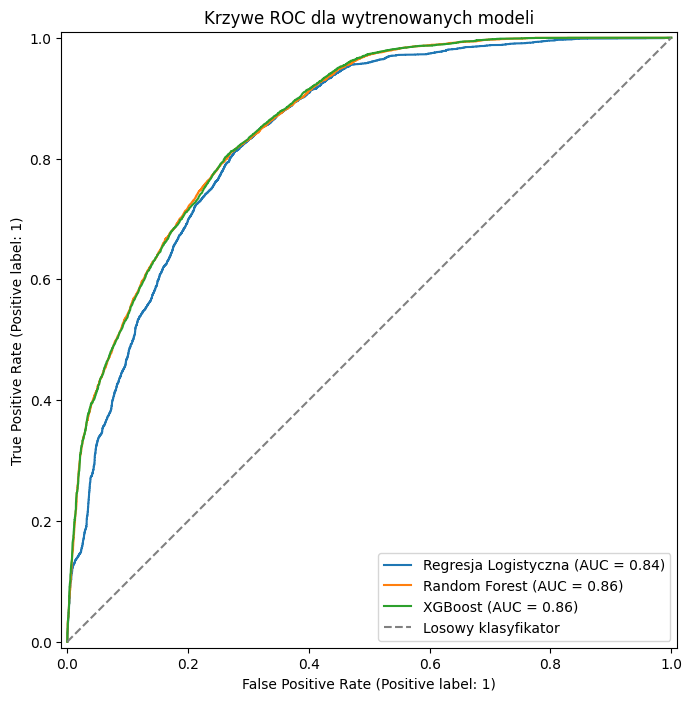

In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

print("--- OCENA MODELI NA ZBIORZE TESTOWYM ---")

modele = {
    "Regresja Logistyczna": pipeline_lr,
    "Random Forest": pipeline_rf,
    "XGBoost": pipeline_xgb
}

fig, ax = plt.subplots(figsize=(10, 8))

for nazwa, model in modele.items():
    # 1. Predykcje
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    
    # 2. Raport klasyfikacji
    print(f"\n[{nazwa}] Raport klasyfikacji:")
    print(classification_report(y_test, y_pred))
    
    # 3. ROC AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)
    print(f"[{nazwa}] ROC AUC: {auc_score:.4f}")
    
    # 4. Rysowanie krzywej ROC na wspólnym wykresie
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=nazwa, ax=ax)

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Losowy klasyfikator')
ax.set_title('Krzywe ROC dla wytrenowanych modeli')
plt.legend()
plt.savefig('krzywe_roc.png', bbox_inches='tight')
plt.show()

### b. Krzywe Uczenia (Learning Curves)
- Diagnostyka Overfittingu - krzywe uczenia udowodnią, że modele są stabilne. 
- Użyto walidacji krzyżowej (StratifiedKFold).

Generowanie krzywej uczenia dla XGBoost (to może potrwać chwile)...


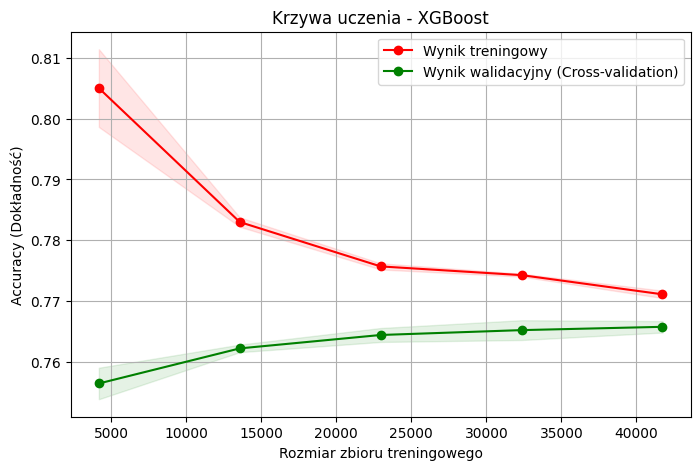

In [5]:
from sklearn.model_selection import learning_curve, StratifiedKFold
import numpy as np

def plot_learning_curve(estimator, title, X, y, cv=3):
    plt.figure(figsize=(8, 5))
    plt.title(title)
    plt.xlabel("Rozmiar zbioru treningowego")
    plt.ylabel("Accuracy (Dokładność)")
    
    # Obliczanie krzywych uczenia
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.grid()
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Wynik treningowy")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Wynik walidacyjny (Cross-validation)")
    
    plt.legend(loc="best")
    plt.show()

# Generujemy krzywą uczenia dla najciekawszego modelu - XGBoost
print("Generowanie krzywej uczenia dla XGBoost (to może potrwać chwile)...")
cv_fold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
plot_learning_curve(pipeline_xgb, "Krzywa uczenia - XGBoost", X_train, y_train, cv=cv_fold)

### Analiza wykresu krzywej uczenia:

- W miarę dostarczania modelowi większej ilości danych, krzywa błędu treningowego oraz krzywa błędu walidacyjnego zbiegają się do siebie.
- Wąski pas ufności (odchylenie standardowe z prób walidacyjnych) na końcowym etapie krzywej dowodzi, że model jest bardzo stabilny i niezależny od konkretnego podziału danych.
- Niewielka szczelina między wynikami na zbiorze treningowym a walidacyjnym jest ostatecznym dowodem na brak istotnego problemu overfittingu, co czyni model w pełni wiarygodnym fundamentem pod dalszą, rygorystyczną analizę za pomocą metod XAI.

# 5. Wyjaśnialność modeli (XAI)

### 5.1: Wyjaśnienia z natury (Regresja Logistyczna)
- Model liniowy tłumaczymy poprzez analizę jego współczynników (wag).
- Największy pozytywny wpływ na szanse adopcyjne mają zmienne związane z brakiem problemów zdrowotnych oraz statusem sterylizacji/kastracji (np. Spayed Female, Neutered Male). 
- Z kolei najsilniejsze wagi ujemne, przypisano do zwierząt o nieznanej płci (często zwierzęta dzikie lub po ciężkich wypadkach) oraz zwierząt niekastrowanych (Intact Male, Intact Female).

--- 5.1 WYJAŚNIENIA Z NATURY (REGRESJA LOGISTYCZNA) ---


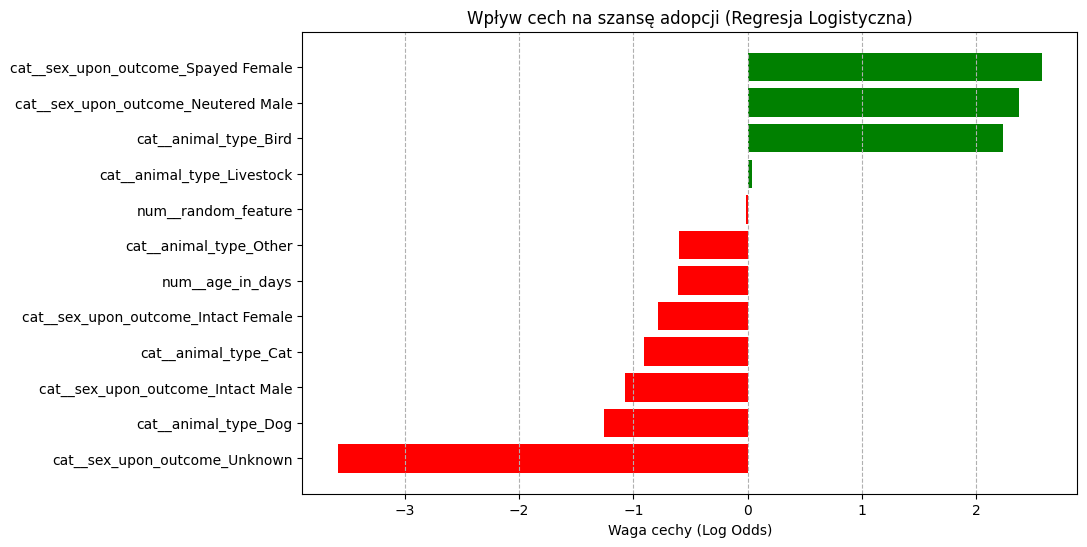

Wykres wag wygenerowany. Cechy na zielono zwiększają szansę na adopcję, na czerwono - zmniejszają.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("--- 5.1 WYJAŚNIENIA Z NATURY (REGRESJA LOGISTYCZNA) ---")

# Wyciągamy nazwy cech z Pipeline'u
feature_names = preprocessor.get_feature_names_out()

# Wyciągamy wagi (współczynniki) z modelu Regresji Logistycznej
coefficients = pipeline_lr.named_steps['classifier'].coef_[0]

# Tworzymy DataFrame dla czytelności
coef_df = pd.DataFrame({
    'Cecha': feature_names,
    'Waga (Wpływ na logit)': coefficients
}).sort_values(by='Waga (Wpływ na logit)', ascending=True)

# Wykres najważniejszych cech
plt.figure(figsize=(10, 6))
plt.barh(coef_df['Cecha'], coef_df['Waga (Wpływ na logit)'], color=['red' if x < 0 else 'green' for x in coef_df['Waga (Wpływ na logit)']])
plt.title("Wpływ cech na szansę adopcji (Regresja Logistyczna)")
plt.xlabel("Waga cechy (Log Odds)")
plt.grid(axis='x', linestyle='--')
plt.savefig('lr_coefficients.png', bbox_inches='tight')
plt.show()

print("Wykres wag wygenerowany. Cechy na zielono zwiększają szansę na adopcję, na czerwono - zmniejszają.")

## 5.2: Wyjaśnienia Globalne
### DALEX - PFI, PDP, Sanity Check

Analiza globalna pozwala zrozumieć uśrednione zachowanie modelu dla całej populacji schroniska.
- Permutation Feature Importance - PFI: Zbadano, które cechy powodują największy spadek precyzji modelu po ich losowym przemieszaniu. Najważniejszymi zmiennymi okazały się wiek (age_in_days) oraz płeć powiązana ze statusem sterylizacji.
- Weryfikacja modelu (Sanity Check): Zgodnie z dobrymi praktykami weryfikacji modeli ML, sprawdzono pozycję dodanej wcześniej kolumny z szumem losowym (random_feature). Wykres PFI udowodnił, że model przypisał jej ważność zerową. Stanowi to matematyczny dowód, że algorytm uczy się rzeczywistych wzorców w danych, a nie zjawisk losowych.
- Partial Dependence Plots - PDP: Wygenerowano profil PDP dla zmiennej wiekowej. Krzywa wykazuje silną nieliniowość – prawdopodobieństwo adopcji jest najwyższe dla zwierząt bardzo młodych (szczenięta i kocięta), gwałtownie spada w pierwszych dwóch latach życia, a następnie stabilizuje się na niskim poziomie dla zwierząt starszych.

In [7]:
import dalex as dx

print("\n--- 5.2 WYJAŚNIENIA GLOBALNE (DALEX) ---")

# Inicjalizacja explainer'a dla modelu XGBoost
explainer_xgb = dx.Explainer(pipeline_xgb, X_test, y_test, label="XGBoost Adoption Model")

# 1. Permutation Feature Importance (Ważność cech)
print("Obliczanie Permutation Feature Importance...")
pfi = explainer_xgb.model_parts(random_state=42)

# Zapisanie figury Plotly i jej wyświetlenie
fig_pfi = pfi.plot(show=False)
fig_pfi.show() # To wyświetli piękny interaktywny wykres w Twoim notatniku!

# Zapis do pliku HTML (możesz go potem otworzyć w dowolnej przeglądarce)
fig_pfi.write_html('dalex_pfi.html')
print("Wykres PFI (Ważność cech) zapisany jako dalex_pfi.html.")


# 2. Partial Dependence Profile (PDP) dla wieku
print("Generowanie wykresów PDP dla wieku...")
pdp_age = explainer_xgb.model_profile(variables=['age_in_days']) 

fig_pdp = pdp_age.plot(show=False)
fig_pdp.show() # Wyświetlenie w notatniku
fig_pdp.write_html('dalex_pdp_age.html')
print("Wykres PDP zapisany jako dalex_pdp_age.html.")


--- 5.2 WYJAŚNIENIA GLOBALNE (DALEX) ---
Preparation of a new explainer is initiated

  -> data              : 15652 rows 4 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 15652 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : XGBoost Adoption Model
  -> predict function  : <function yhat_proba_default at 0x000002C75985D760> will be used (default)
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 0.000179, mean = 0.426, max = 0.978
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.968, mean = -0.00277, max = 0.996
  -> model_info        : package sklearn

A new explainer has been created!
Obliczanie Permutation Feature Importance...


Wykres PFI (Ważność cech) zapisany jako dalex_pfi.html.
Generowanie wykresów PDP dla wieku...


Calculating ceteris paribus: 100%|██████████| 1/1 [00:00<00:00, 16.96it/s]


Wykres PDP zapisany jako dalex_pdp_age.html.


### 5.3: Wyjaśnienia Lokalne
Wyjaśnienia globalne mogą maskować nietypowe, jednostkowe przypadki. Aby zbadać, jak model decyduje "tu i teraz", należy wybrać z testowego zbioru danych pojedynczą instancję.

In [ ]:
import shap
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

print("\n--- 5.3 WYJAŚNIENIA LOKALNE (SHAP i LIME) ---")

# Wybieramy jedno zwierzę ze zbioru testowego do analizy (np. indeks 10)
instance_idx = 10
instance_to_explain = X_test.iloc[[instance_idx]]
print(f"Dane analizowanego zwierzęcia:\n{instance_to_explain.to_dict('records')[0]}")
print(f"Prawdziwy wynik (1=Adopcja, 0=Inne): {y_test.iloc[instance_idx]}")
print(f"Predykcja XGBoost: {pipeline_xgb.predict(instance_to_explain)[0]}")

# --- PRZYGOTOWANIE DANYCH ---
# Przepuszczamy dane przez preprocessor, aby XAI otrzymało czyste liczby (One-Hot Encoding)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)
instance_transformed = preprocessor.transform(instance_to_explain)

# Jeśli preprocessor zwrócił macierz rzadką (sparse matrix), zmieniamy ją na zwykłą tablicę
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()
    X_test_transformed = X_test_transformed.toarray()
    instance_transformed = instance_transformed.toarray()

# Wyciągamy wygenerowane nazwy kolumn (np. 'cat__animal_type_Dog')
feature_names_out = preprocessor.get_feature_names_out()

# --- SHAP ---
print("\nGenerowanie wykresu SHAP...")
explainer_shap = shap.TreeExplainer(pipeline_xgb.named_steps['classifier'])
shap_values = explainer_shap(X_test_transformed)

plt.figure(figsize=(10, 6))
# Rysujemy Waterfall plot dla wybranego zwierzęcia
shap.plots.waterfall(shap_values[instance_idx], show=False)
plt.savefig('shap_waterfall.png', bbox_inches='tight')
plt.close()
print("Wykres SHAP Waterfall zapisany.")

# --- LIME  ---
print("\nPrzeprowadzanie testu stabilności LIME...")

# Przekazujemy do LIME przetworzone dane numeryczne i odpowiednie nazwy kolumn
explainer_lime = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformed,
    feature_names=feature_names_out,
    class_names=['Inne', 'Adopcja'],
    mode='classification',
    random_state=42
)

# Ponieważ przekazaliśmy przetransformowane dane, predykcję robi sam klasyfikator
predict_fn_lime = pipeline_xgb.named_steps['classifier'].predict_proba

# Uruchamiamy LIME 5 razy z różnymi seedami (test stabilności)
for i in range(1, 6):
    np.random.seed(i * 10) 
    exp = explainer_lime.explain_instance(
        data_row=instance_transformed[0], 
        predict_fn=predict_fn_lime,
        num_features=4
    )
    # Wypisujemy dwie najważniejsze cechy wg LIME w danej iteracji
    top_features = exp.as_list()[:2]
    print(f"LIME (Próba {i}): Najważniejsze cechy to {top_features}")


--- 5.3 WYJAŚNIENIA LOKALNE (SHAP i LIME) ---
Dane analizowanego zwierzęcia:
{'age_in_days': 35.0, 'random_feature': 0.14540657737161078, 'animal_type': 'Cat', 'sex_upon_outcome': 'Intact Male'}
Prawdziwy wynik (1=Adopcja, 0=Inne): 0
Predykcja XGBoost: 0

Generowanie wykresu SHAP...
Wykres SHAP Waterfall zapisany.

Przeprowadzanie testu stabilności LIME...
LIME (Próba 1): Najważniejsze cechy to [('cat__sex_upon_outcome_Unknown <= 0.00', 0.3919026149665414), ('cat__sex_upon_outcome_Intact Male > 0.00', -0.3167322180178454)]
LIME (Próba 2): Najważniejsze cechy to [('cat__sex_upon_outcome_Unknown <= 0.00', 0.408105751303857), ('cat__sex_upon_outcome_Intact Male > 0.00', -0.30962610616317904)]
LIME (Próba 3): Najważniejsze cechy to [('cat__sex_upon_outcome_Unknown <= 0.00', 0.40641335430234377), ('cat__sex_upon_outcome_Intact Male > 0.00', -0.31811328033623665)]
LIME (Próba 4): Najważniejsze cechy to [('cat__sex_upon_outcome_Unknown <= 0.00', 0.405440711038706), ('cat__sex_upon_outcome_In

## Analiza SHAP i LIME:
Ze zbioru testowego wybrano przypadek 35-dniowego, niekastrowanego kota (kocur), a model zgodnie z prawdą przewidział dla niego klasę 0, czyli brak adopcji.

- SHAP: Wykorzystując strukturę algorytmu TreeExplainer, wygenerowano wykres kaskadowy (Waterfall plot). Pokazał on, w jaki sposób każda cecha dodaje lub odejmuje wartość od predykcji bazowej (oczekiwanej wartości dla całego zbioru). SHAP wyraźnie wskazał, że młody wiek przesuwał predykcję w kierunku pozytywnym, jednak zmienna kategorialna Intact Male (brak kastracji) była na tyle silnym czynnikiem negatywnym, że ostatecznie "ściągnęła" logit poniżej progu decyzyjnego.

- LIME: Metoda LIME buduje lokalny, interpretowalny model liniowy wokół badanej obserwacji, ucząc się na wygenerowanych losowo próbkach (perturbacjach). Z uwagi na stochastyczną naturę tej metody, przeprowadzono Test Stabilności. Uruchomiono algorytm LIME 5-krotnie dla tego samego kota, za każdym razem zmieniając ziarno losowości (random_state).
    - Wynik: Narzędzie wykazało wyjątkowo wysoką stabilność. W każdej z 5 iteracji algorytm zidentyfikował dokładnie te same dwie wiodące cechy (pozytywny wpływ zidentyfikowanej płci i silny negatywny wpływ faktu bycia niekastrowanym kocurem), a ich wagi różniły się jedynie na trzecim miejscu po przecinku (np. -0.316 vs -0.309). Udowadnia to, że przestrzeń decyzyjna modelu wokół tej instancji jest gładka i niepodatna na losowy szum.

# Human-Centered XAI

Modele, kody, matematyka bywają niezrozumiałe dla odbiorców spoza branży, dlatego tak ważny jest paradygmat human-centered XAI, który mówi o transformowaniu wyników na język użyteczny, czy to dla zwykłego Kowalskiego, czy w jakiejś konkretnej profesji. 

Podzieliłabym możliwe opisy na dwie główne kategorie:

Język domenowy:
"System poprawnie ocenił, że ten konkretny kot może mieć trudności z szybką adopcją. Choć jego młody wiek działa na jego korzyść, główną przeszkodą zidentyfikowaną przez algorytm jest fakt, że nie przeszedł on jeszcze zabiegu kastracji. Z punktu widzenia strategii operacyjnej, priorytetem powinno być skierowanie zwierzęcia na zabieg weterynaryjny, co według predykcji modelu drastycznie zwiększy jego szanse na znalezienie nowego domu."

Język techniczny:
"Model zespołu drzew XGBoost poprawnie sklasyfikował instancję jako klasę negatywną. Analiza lokalna za pomocą metody SHAP wykazuje, że głównym negatywnym czynnikiem był wektor 'Intact Male', który silnie obniżył ostateczny logit predykcji, przeważając nad pozytywnym wpływem niskiej wartości zmiennej numerycznej 'age_in_days'. Test stabilności z wykorzystaniem agnostycznego algorytmu LIME (5 niezależnych iteracji) potwierdza wysoką ufność wyjaśnienia – odnotowano znikomą wariancję we wskazaniach kluczowych driverów predykcji."